In [1]:
import os
import sys

In [2]:
sys.path.append(os.path.join(os.getcwd(), "../"))

In [3]:
import matplotx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from datetime import datetime

In [5]:
from src.python.utils import load_file_chunks

In [6]:
plt.style.use(matplotx.styles.dracula)

In [7]:
DATA_PATH = os.path.join(os.getcwd(), "../", "data")
OPTIONS_DATA_PATH = os.path.join(DATA_PATH, "spx_options_processed.csv")

In [8]:
start_date = datetime(2015, 1, 1)
end_date = datetime(2015, 2, 1)

In [9]:
df = load_file_chunks(OPTIONS_DATA_PATH, start_date, end_date)

In [10]:
df.head()

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,...,vega,theta,optionid,spot,spx_return,dte,mid,bid_ask_spread,moneyness,log_moneyness
1932708,2015-01-02,2015-01-17,C,1000.0,1056.7,1059.9,1500,41884,1.598820,0.993924,...,6.129469,-106.8664,101234072,2058.2,-0.00034,15,1058.30,3.2,0.485861,-0.721832
1932709,2015-01-02,2015-01-17,C,1025.0,1031.7,1034.9,0,0,1.548029,0.993750,...,6.300900,-106.2628,101234073,2058.2,-0.00034,15,1033.30,3.2,0.498008,-0.697139
1932710,2015-01-02,2015-01-17,C,1050.0,1006.7,1009.8,0,52,1.490604,0.993763,...,6.288437,-100.9584,101234074,2058.2,-0.00034,15,1008.25,3.1,0.510155,-0.673042
1932711,2015-01-02,2015-01-17,C,1075.0,981.7,984.8,0,4,1.442365,0.993582,...,6.466263,-100.3422,101234075,2058.2,-0.00034,15,983.25,3.1,0.522301,-0.649511
1932712,2015-01-02,2015-01-17,C,1100.0,956.7,959.9,0,425,1.402610,0.993187,...,6.850747,-104.3517,101234076,2058.2,-0.00034,15,958.30,3.2,0.534448,-0.626522


In [11]:
df.tail()

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,...,vega,theta,optionid,spot,spx_return,dte,mid,bid_ask_spread,moneyness,log_moneyness
2013666,2015-01-30,2015-06-30,P,2450.0,464.40,475.60,0,0,0.175458,-0.958429,...,96.92561,-48.563960,106123051,1994.99,-0.012992,151,470.000,11.20,1.228076,0.205449
2013667,2015-01-30,2015-06-30,P,2500.0,514.20,525.40,0,0,0.187366,-0.961659,...,89.28925,-48.189610,104605642,1994.99,-0.012992,151,519.800,11.20,1.253139,0.225652
2013668,2015-01-30,2015-06-30,P,850.0,0.10,0.95,0,0,0.498217,-0.002514,...,10.00224,-6.098301,106720275,1994.99,-0.012992,151,0.525,0.85,0.426067,-0.853158
2013669,2015-01-30,2015-06-30,P,900.0,0.30,1.15,0,38,0.483238,-0.003483,...,13.41596,-7.940055,104605644,1994.99,-0.012992,151,0.725,0.85,0.451130,-0.796000
2013670,2015-01-30,2015-06-30,P,950.0,0.55,1.40,0,0,0.468055,-0.004709,...,17.57365,-10.082660,106720276,1994.99,-0.012992,151,0.975,0.85,0.476193,-0.741932


In [12]:
df.describe()

,date,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,spot,spx_return,dte,mid,bid_ask_spread,moneyness,log_moneyness
count,80963,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,8.096300e+04,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000,80963.000000
mean,2015-01-16 13:03:34.542445,1819.034497,125.905825,128.913055,163.051097,1647.469301,0.261202,0.143369,0.001274,138.741969,-93.301122,1.058689e+08,2028.166784,-0.001593,60.530922,127.409440,3.007230,0.896961,-0.123558
min,2015-01-02 00:00:00,200.000000,0.050000,0.100000,0.000000,0.000000,0.050190,-0.999513,0.000000,0.000826,-622.212000,1.012341e+08,1992.670000,-0.018278,8.000000,0.075000,0.050000,0.100251,-2.300077
25%,2015-01-08 00:00:00,1635.000000,4.200000,4.900000,0.000000,0.000000,0.164073,-0.150473,0.000257,38.731725,-134.132950,1.058888e+08,2011.270000,-0.009248,35.000000,4.550000,0.800000,0.806530,-0.215014
50%,2015-01-15 00:00:00,1850.000000,39.100000,40.900000,0.000000,4.000000,0.236000,-0.005404,0.000826,105.119300,-81.458710,1.061822e+08,2025.900000,-0.005492,57.000000,40.000000,1.700000,0.910990,-0.093223
75%,2015-01-23 00:00:00,2045.000000,187.500000,192.100000,3.000000,150.000000,0.314879,0.783207,0.002010,220.058200,-37.074465,1.063956e+08,2044.810000,0.004732,77.000000,189.800000,3.400000,1.008167,0.008134
max,2015-01-30 00:00:00,3500.000000,1556.500000,1559.500000,61151.000000,150345.000000,2.976005,0.999516,0.011269,570.204800,33.986350,1.067203e+08,2063.150000,0.017888,179.000000,1558.000000,12.000000,1.754395,0.562124
std,NaN,295.348772,178.336568,180.767848,1119.224643,7032.612649,0.142921,0.591322,0.001288,117.975180,75.677860,1.046844e+06,21.525934,0.010478,36.317467,179.548517,3.348613,0.145816,0.178134


#### Data Analysis and Outliers:

In [13]:
df[df['theta'] > 0]

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,...,vega,theta,optionid,spot,spx_return,dte,mid,bid_ask_spread,moneyness,log_moneyness
1933008,2015-01-02,2015-02-20,C,1175.0,877.9,880.7,0,0,0.442849,0.997751,...,0.526407,28.851780,105696998,2058.20,-0.000340,49,879.30,2.8,0.570887,-0.560564
1933009,2015-01-02,2015-02-20,C,1200.0,852.8,855.9,0,0,0.470235,0.997337,...,1.568166,26.869200,105696999,2058.20,-0.000340,49,854.35,3.1,0.583034,-0.539510
1933010,2015-01-02,2015-02-20,C,1220.0,833.0,835.9,0,0,0.495452,0.996547,...,3.394333,23.213950,105728747,2058.20,-0.000340,49,834.45,2.9,0.592751,-0.522981
1933011,2015-01-02,2015-02-20,C,1225.0,828.0,830.9,0,0,0.491407,0.996548,...,3.392382,23.259060,105697000,2058.20,-0.000340,49,829.45,2.9,0.595180,-0.518891
1933012,2015-01-02,2015-02-20,C,1250.0,803.1,806.0,0,0,0.495388,0.995794,...,5.034629,20.039920,105697001,2058.20,-0.000340,49,804.55,2.9,0.607327,-0.498688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013570,2015-01-30,2015-06-30,C,1250.0,727.6,738.0,0,0,0.315816,0.983746,...,30.507260,20.493740,104605548,1994.99,-0.012992,151,732.80,10.4,0.626570,-0.467495
2013571,2015-01-30,2015-06-30,C,1275.0,703.2,713.5,0,0,0.318265,0.980658,...,39.668060,16.717020,104605549,1994.99,-0.012992,151,708.35,10.3,0.639101,-0.447693
2013572,2015-01-30,2015-06-30,C,1300.0,679.1,689.5,0,0,0.325296,0.975706,...,53.563480,10.698290,104605550,1994.99,-0.012992,151,684.30,10.4,0.651632,-0.428275
2013573,2015-01-30,2015-06-30,C,1325.0,654.7,665.0,0,0,0.321279,0.972642,...,61.764260,7.612079,104605551,1994.99,-0.012992,151,659.85,10.3,0.664164,-0.409227


In [14]:
df[df['theta'] > 0]['cp_flag'].value_counts()

cp_flag
C    3708
Name: count, dtype: int64

In [15]:
df[df['theta'] > 0]['delta'].describe()

count    3708.000000
mean        0.988227
std         0.006643
min         0.962074
25%         0.984006
50%         0.989185
75%         0.993386
max         0.999516
Name: delta, dtype: float64

**Analysis:**
All of the above selected are all calls with delta close to 1.0, so deep ITM calls. A deep in-the-money call option (delta ~1) behaves like:
- You already own the stock/index
- But you paid part of its price upfront (the strike)
- So what is left is basically financing

It is like buying the stock on credit - economically equivalent to holding stock minus a bond. In effect, buying the stock here means you don't pay full price today, but pay the strike later at expiry. You are delaying the payment, and this delay has value because money earns interest:
- Higher interest rates means delaying the payment is more valuable
- This slightly affects the option price
Normally, theta is negative and options lose value over time. A lot of the value of deep ITM calls behave weird as their value is just "financing maths", not optionality. Part of the decay is just the model correcting the interest-rate difference over time.

**Why don't we care about these options?**
Deep ITM calls are not interesting because:
- They behave almost exactly like a stock, there is no real volatility exposure
- They are rarely traded, so liquidity is bad
- Bid/ask spreads are wide, meaning these are expensive to trade
- Nothing to arbitrage as there is no useful strategy edge

In [16]:
df = df[df['theta'] < 0]

In [17]:
df[df['impl_volatility'] > 2.0]

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,...,vega,theta,optionid,spot,spx_return,dte,mid,bid_ask_spread,moneyness,log_moneyness
1932894,2015-01-02,2015-01-17,C,500.0,1556.5,1559.5,0,2505,2.936215,0.997112,...,2.826787,-84.99251,101234121,2058.20,-0.000340,15,1558.00,3.0,0.242931,-1.414979
1932895,2015-01-02,2015-01-17,C,550.0,1506.4,1509.6,0,0,2.742995,0.996943,...,3.012184,-84.54140,101234122,2058.20,-0.000340,15,1508.00,3.2,0.267224,-1.319669
1932896,2015-01-02,2015-01-17,C,600.0,1456.6,1459.5,0,0,2.582655,0.996654,...,3.325203,-89.19111,101234123,2058.20,-0.000340,15,1458.05,2.9,0.291517,-1.232657
1932897,2015-01-02,2015-01-17,C,650.0,1406.6,1409.5,0,0,2.420727,0.996465,...,3.527442,-88.58294,101234124,2058.20,-0.000340,15,1408.05,2.9,0.315810,-1.152615
1932898,2015-01-02,2015-01-17,C,700.0,1356.6,1359.8,0,66,2.309314,0.995885,...,4.140422,-103.02740,101234125,2058.20,-0.000340,15,1358.20,3.2,0.340103,-1.078507
1932899,2015-01-02,2015-01-17,C,750.0,1306.6,1309.8,100,550,2.168318,0.995654,...,4.380956,-102.23310,101234126,2058.20,-0.000340,15,1308.20,3.2,0.364396,-1.009514
1932900,2015-01-02,2015-01-17,C,775.0,1281.6,1284.8,0,0,2.101392,0.995534,...,4.504885,-101.81270,101234127,2058.20,-0.000340,15,1283.20,3.2,0.376543,-0.976724
1932901,2015-01-02,2015-01-17,C,800.0,1256.6,1259.8,0,0,2.036633,0.995411,...,4.631505,-101.37740,101234128,2058.20,-0.000340,15,1258.20,3.2,0.388689,-0.944975
1937043,2015-01-05,2015-01-17,C,600.0,1419.1,1422.0,0,0,2.853421,0.997063,...,2.600900,-104.57780,101234123,2020.58,-0.018278,12,1420.55,2.9,0.296944,-1.214210
1937044,2015-01-05,2015-01-17,C,650.0,1369.1,1372.0,0,0,2.671988,0.996891,...,2.761922,-103.89330,101234124,2020.58,-0.018278,12,1370.55,2.9,0.321690,-1.134168


In [18]:
df = df[df['impl_volatility'] < 2.0]

In [19]:
df.head()

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,...,vega,theta,optionid,spot,spx_return,dte,mid,bid_ask_spread,moneyness,log_moneyness
1932708,2015-01-02,2015-01-17,C,1000.0,1056.7,1059.9,1500,41884,1.598820,0.993924,...,6.129469,-106.8664,101234072,2058.2,-0.00034,15,1058.30,3.2,0.485861,-0.721832
1932709,2015-01-02,2015-01-17,C,1025.0,1031.7,1034.9,0,0,1.548029,0.993750,...,6.300900,-106.2628,101234073,2058.2,-0.00034,15,1033.30,3.2,0.498008,-0.697139
1932710,2015-01-02,2015-01-17,C,1050.0,1006.7,1009.8,0,52,1.490604,0.993763,...,6.288437,-100.9584,101234074,2058.2,-0.00034,15,1008.25,3.1,0.510155,-0.673042
1932711,2015-01-02,2015-01-17,C,1075.0,981.7,984.8,0,4,1.442365,0.993582,...,6.466263,-100.3422,101234075,2058.2,-0.00034,15,983.25,3.1,0.522301,-0.649511
1932712,2015-01-02,2015-01-17,C,1100.0,956.7,959.9,0,425,1.402610,0.993187,...,6.850747,-104.3517,101234076,2058.2,-0.00034,15,958.30,3.2,0.534448,-0.626522


In [20]:
print(df[df['best_bid'] < 0].shape)

(0, 21)


In [21]:
print(df[df['best_bid'] > df['best_offer']].shape)

(0, 21)


In [22]:
print(df[df['mid'] <= 0].shape)

(0, 21)


In [23]:
calls = df[df['cp_flag'] == 'C']
puts = df[df['cp_flag'] == 'P']
print(calls[~calls['delta'].between(0, 1)].shape)
print(puts[~puts['delta'].between(-1, 0)].shape)

(0, 21)
(0, 21)


In [24]:
print(df[df['moneyness'] < 0.5].shape)

(843, 21)


In [25]:
print(df[df['moneyness'] > 1.5].shape)

(7, 21)


In [26]:
df = df[df['moneyness'].between(0.5, 1.5)]

In [27]:
df.shape

(76369, 21)

In [28]:
df.isnull().sum()

date               0
exdate             0
cp_flag            0
strike_price       0
best_bid           0
best_offer         0
volume             0
open_interest      0
impl_volatility    0
delta              0
gamma              0
vega               0
theta              0
optionid           0
spot               0
spx_return         0
dte                0
mid                0
bid_ask_spread     0
moneyness          0
log_moneyness      0
dtype: int64

#### Open Interest Heatmap:
A 2D map showing where contracts are concentrated. For:
- Identifying max pain / pinning levels
- Dealer exposure zones
- Magnet strikes near expiry

In [29]:
oi_matrix = df.pivot_table(
    index='strike_price',
    columns='exdate',
    values='open_interest',
    aggfunc='sum'
).fillna(0)

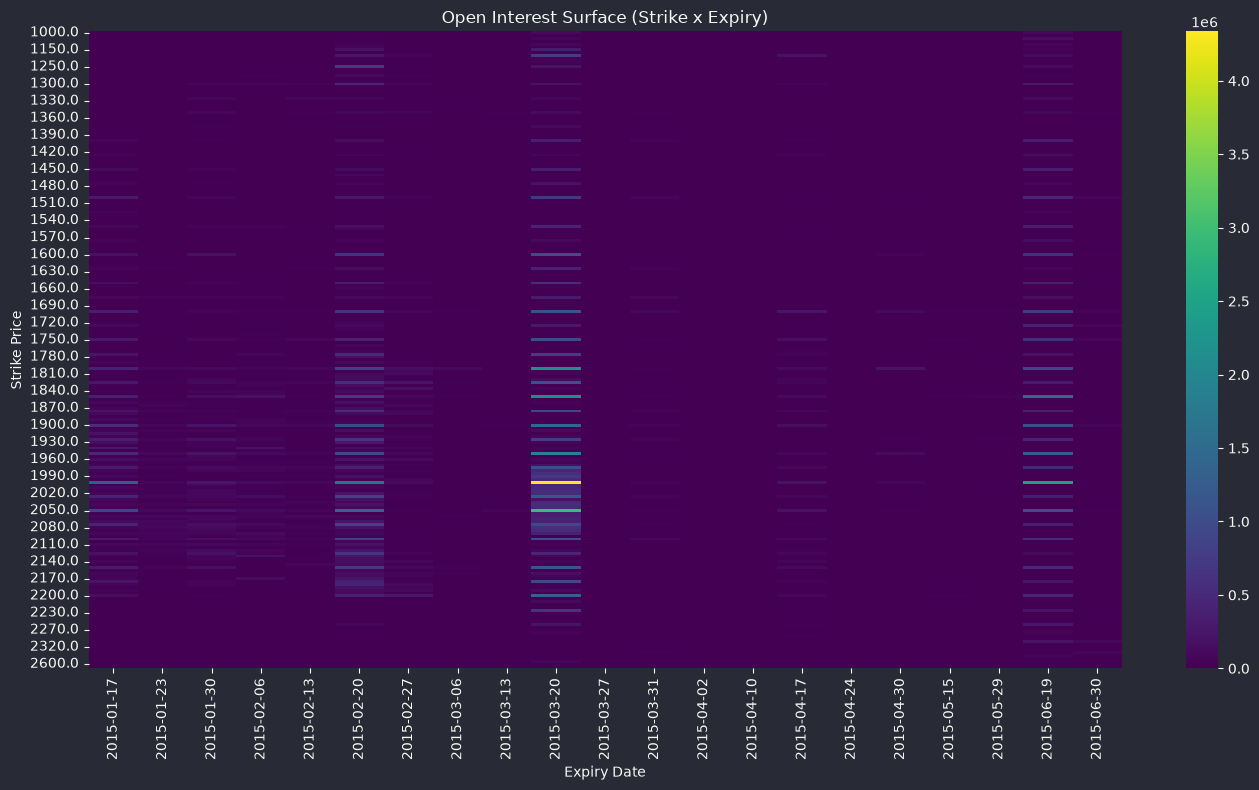

In [30]:
plt.figure(figsize=(14,8))

sns.heatmap(
    oi_matrix,
    cmap='viridis',
    linewidths=0.0
)

plt.title("Open Interest Surface (Strike x Expiry)")
plt.xlabel("Expiry Date")
plt.ylabel("Strike Price")
plt.tight_layout()
plt.show()

#### Volatility Smile:
Theoretically, implied volatility should be the same for all strikes. In real markets it is not:
- Deep out-of-the-money puts - higher implied volatility
- At-the-money options - lower implied volatility
- Deep out-of-the-money calls - sometimes higher, depends on asset

Plotting this, we should get a smile, or more commonly in equities, a skew.

The volatility smile is the market telling us that returns are not normally distributed, and tail risks are priced. It reflects:
- Skewed return distribution (usually downside-heavy in equities)
- Fat tails (big moves happen more than Gaussian assumptions)
- Crash risk premium (puts are expensive because people fear drops)
- Supply/demand imbalance in options markets
- Market beliefs about asymmetry in risk

In [31]:
df['date'].unique()

<DatetimeArray>
['2015-01-02 00:00:00', '2015-01-05 00:00:00', '2015-01-06 00:00:00',
 '2015-01-07 00:00:00', '2015-01-08 00:00:00', '2015-01-09 00:00:00',
 '2015-01-12 00:00:00', '2015-01-13 00:00:00', '2015-01-14 00:00:00',
 '2015-01-15 00:00:00', '2015-01-16 00:00:00', '2015-01-20 00:00:00',
 '2015-01-21 00:00:00', '2015-01-22 00:00:00', '2015-01-23 00:00:00',
 '2015-01-26 00:00:00', '2015-01-27 00:00:00', '2015-01-28 00:00:00',
 '2015-01-29 00:00:00', '2015-01-30 00:00:00']
Length: 20, dtype: datetime64[us]

In [32]:
# Single Date and Expiry Date
initial_date = datetime(2015, 1, 2)
expiry_date = '2015-03-20'

In [33]:
mask = (df['date'] == initial_date) & (df['exdate'] == expiry_date)
slice_df = df[mask]

In [34]:
print(df['date'].unique()[:5])
print(df[df['date'] == initial_date]['exdate'].unique())
print(slice_df.shape)

<DatetimeArray>
['2015-01-02 00:00:00', '2015-01-05 00:00:00', '2015-01-06 00:00:00',
 '2015-01-07 00:00:00', '2015-01-08 00:00:00']
Length: 5, dtype: datetime64[us]
<StringArray>
['2015-01-17', '2015-02-20', '2015-03-20', '2015-04-17', '2015-06-19',
 '2015-01-23', '2015-01-30', '2015-02-06', '2015-02-13', '2015-02-27',
 '2015-03-06', '2015-03-13', '2015-03-27', '2015-03-31', '2015-04-30',
 '2015-05-29', '2015-06-30']
Length: 17, dtype: str
(279, 21)


In [35]:
print(df['exdate'].dtype)
print(type(df['exdate'].iloc[0]))

str
<class 'str'>


In [36]:
calls = slice_df[slice_df['cp_flag'] == 'C']
puts = slice_df[slice_df['cp_flag'] == 'P']

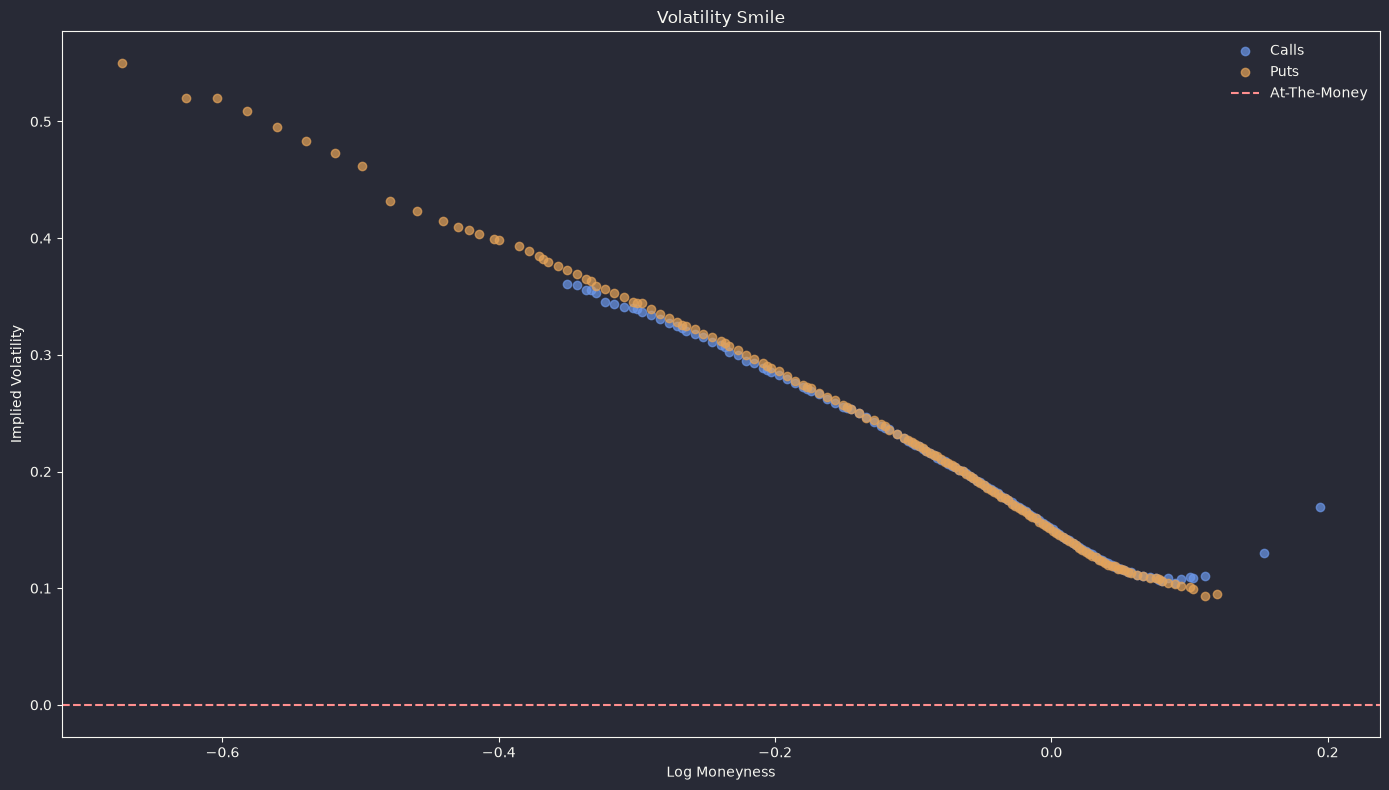

In [37]:
plt.figure(figsize=(14,8))

plt.scatter(calls['log_moneyness'], calls['impl_volatility'], color="#6c97e9", label='Calls', alpha=0.7)
plt.scatter(puts['log_moneyness'], puts['impl_volatility'], color="#e4a359", label='Puts', alpha=0.7)

plt.axhline(y=0, color="#ff8f8f", linestyle='--', label='At-The-Money')

plt.title("Volatility Smile")
plt.xlabel("Log Moneyness")
plt.ylabel("Implied Volatility")
plt.legend()
plt.tight_layout()
plt.show()

What can we use this volatility smile for?
1. Pricing options correctly
> Use a volatility surface instead of a single volatility. Implied volatility depenends on strike and maturity. Every option gets a different volatility input. This is essential for accurate pricing, market making and arbitrage checks.

2. Risk management
> The smile encodes where the market thinks crashes or spikes live. It is used to measure tail risk pricing, compute better Greeks (vanna, volga), stress test portfolios under skew chances and hedge nonlinear exposure more realistically.

3. Trading volatility itself
> The shape of the smike is tradeable. If skew is "too steep" vs volatility, we sell crash protection and buy upside skew. If the smile is too flat, we expect demand for protection or dislocations. This is used in vol arbitrage strategies, or dispersion and skew trades.

4. Market sentiment and regime detection
> Changes in the smile matter more than its level. Steepening skew means fear is rising, flattening means complacency or supply of protection, smile shifts across maturities means regime changes in risk pricing.

5. Model calibration
> Any serious pricing model beyond Black-Scholes must reproduce the smile. It is used to calibrate stochastic volatility models, fit local volatility surfaces and ensure there is no arbitrage in the surface.

#### Volatility Term Structure
For one date in time, we take options across different expiries, and look at the ATM implied volatility for each expiry. This is ATM = strike where log-moneyness is nearly 0, so the strike price is near the spot price. This curve tells us how expensive volatility is depending on how far into the future we look:

> Normal markets (most of the time):
- Curve is upward sloping
- Short-dated IV < long-dated IV
This is because in the near-term it is often quiet unless there is an event, and it is more uncertain in the long term. This is called volatility contango.

> Stress / crisis periods:
- Curve often becomes downward sloping or inverted
- Short-dated IV spikes a lot
- Long-dated IV rises but much less
This is due to panic being immediate and concentrated in the near term, and long-term outlook doesn't change as much. This is volatility backwardation.

> Event-driven markets:
- Often see a bump/spike at a specific expiry, which could be an earnings date or CPI/Fed meeing.
The curve is not smooth, and has humps.

This is not just a chart, it is the price of future uncertainty. You can trade the shape of the curve, use it to understand risk premium, make hedging decisions, or detect certain macro regimes - daily use for a risk regime signal. More importantly, you can decompose the volatility surface into:
- Term structure (DTE dimension)
- Skew (strike dimension)
From just term structure, we can infer the market's implied future volatility path and expected variance over time.

In [38]:
term_structure_date = datetime(2015, 1, 2)

In [39]:
print(df[df['date'] == initial_date]['exdate'].unique())

<StringArray>
['2015-01-17', '2015-02-20', '2015-03-20', '2015-04-17', '2015-06-19',
 '2015-01-23', '2015-01-30', '2015-02-06', '2015-02-13', '2015-02-27',
 '2015-03-06', '2015-03-13', '2015-03-27', '2015-03-31', '2015-04-30',
 '2015-05-29', '2015-06-30']
Length: 17, dtype: str


In [40]:
unique_dates = df[df['date'] == initial_date]['exdate'].unique()

In [41]:
ts_df = df[(df['date'] == term_structure_date) & (df['exdate'].isin(unique_dates))]

In [42]:
atm_idx = ts_df.groupby('exdate')['log_moneyness'].apply(lambda x: x.abs().idxmin())

In [43]:
atm_df = ts_df.loc[atm_idx]

In [44]:
atm_df = atm_df.sort_values('dte')

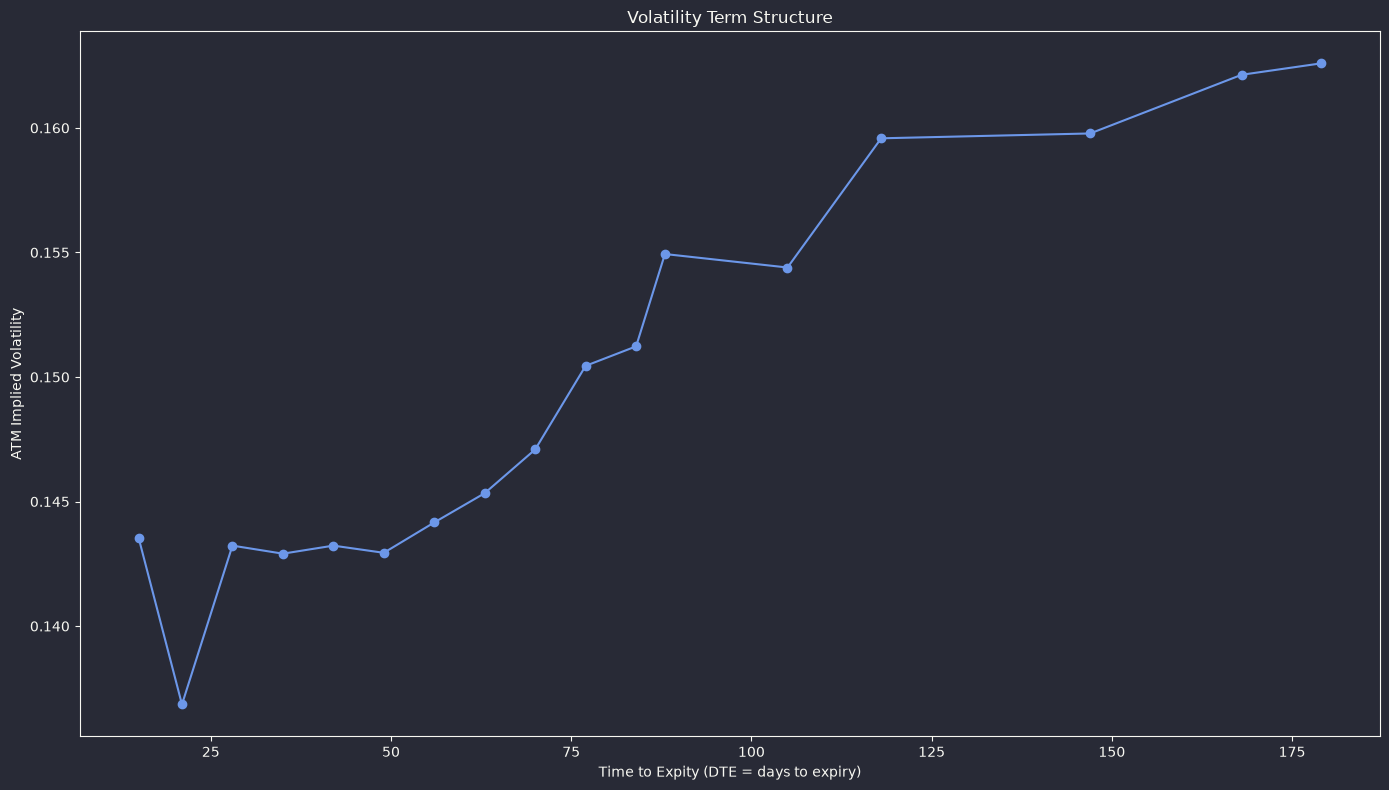

In [ ]:
plt.figure(figsize=(14,8))

plt.scatter(atm_df['dte'], atm_df['impl_volatility'], color="#6c97e9")
plt.plot(atm_df['dte'], atm_df['impl_volatility'], color="#6c97e9")


plt.title("Implied Volatility Term Structure")
plt.xlabel("Time to Expiry (DTE = days to expiry)")
plt.ylabel("ATM Implied Volatility")
plt.tight_layout()
plt.show()

**Term Structure Analysis:**

_The upward slope makes sense here_ - when markets are calm, short-dated volatility is cheap because there is not much expected to happen in the next 2-3 weeks. Longer dated volatility is higher because there is more time for uncertainty to accumulate. The market is pricing in mean reversion - short term calm, longer term uncertainty.

_Dip at ~20 DTE_ - likely a specific expiry with unusual pricing, possibly a weekly option with low liquidity where the ATM proxy isn't perfectly clean.

#### Comparing Term Structures & VIX:
